## Initializing data frame

In [1]:
import pandas as pd
pref_germ_df = pd.read_json("./results/preferential_germline_1000.json", dtype=str)
pref_mut_df = pd.read_json("./results/preferential_mutated_1000.json", dtype=str)
uni_germ_df = pd.read_json("./results/uniform_germline_1000.json", dtype=str)
uni_mut_df = pd.read_json("./results/uniform_mutated_1000.json", dtype=str)
rand_germ_df = pd.read_json("./results/random_germline_1000.json", dtype=str)
rand_mut_df = pd.read_json("./results/random_mutated_1000.json", dtype=str)
m8M_germ_df = pd.read_parquet("./results/8M-F_germline_10000.parquet")
m8M_mut_df = pd.read_parquet("./results/8M-F_mutated_10000.parquet")
m35M_germ_df = pd.read_parquet("./results/35M-F_germline_10000.parquet")
m35M_mut_df = pd.read_parquet("./results/35M-F_mutated_10000.parquet")
m150M_germ_df = pd.read_parquet("./results/150M-F_germline_10000.parquet")
m150M_mut_df = pd.read_parquet("./results/150M-F_mutated_10000.parquet")
m350M_germ_df = pd.read_parquet("./results/350M-F_germline_10000.parquet")
m350M_mut_df = pd.read_parquet("./results/350M-F_mutated_10000.parquet")
m650M_germ_df = pd.read_parquet("/home/jovyan/work/AbLM-Metric/results/650M-F_unmutated-per-position-inference.parquet")
m650M_mut_df = pd.read_parquet("/home/jovyan/work/AbLM-Metric/results/650M-F_mutated-per-position-inference.parquet")


# for model in ["8M-F", "35M-F", "150M-F", "350M-F", "650M-F"]:
#     for data_type in ["Germline", "Mutated"]:
#         df = pd.read_parquet(f"./results/{model}_{data_type.lower()}_10000.parquet")
#         df["model"], df["data_type"], df["study"] = model, data_type, "size"
#         frames.append(df)

pref_germ_df["model"] = "Preferential"
pref_mut_df["model"] = "Preferential"
uni_germ_df["model"] = "Uniform"
uni_mut_df["model"] = "Uniform"
rand_germ_df["model"] = "Random"
rand_mut_df["model"] = "Random"
m8M_germ_df["model"] = "8M-F"
m8M_mut_df["model"] = "8M-F"
m35M_germ_df["model"] = "35M-F"
m35M_mut_df["model"] = "35M-F"
m150M_germ_df["model"] = "150M-F"
m150M_mut_df["model"] = "150M-F"
m350M_germ_df["model"] = "350M-F"
m350M_mut_df["model"] = "350M-F"
m650M_germ_df["model"] = "650M-F"
m650M_mut_df["model"] = "650M-F"

pref_germ_df["data_type"] = "Germline"
pref_mut_df["data_type"] = "Mutated"
uni_germ_df["data_type"] = "Germline"
uni_mut_df["data_type"] = "Mutated"
rand_germ_df["data_type"] = "Germline"
rand_mut_df["data_type"] = "Mutated"
m8M_germ_df["data_type"] = "Germline"
m8M_mut_df["data_type"] = "Mutated"
m35M_germ_df["data_type"] = "Germline"
m35M_mut_df["data_type"] = "Mutated"
m150M_germ_df["data_type"] = "Germline"
m150M_mut_df["data_type"] = "Mutated"
m350M_germ_df["data_type"] = "Germline"
m350M_mut_df["data_type"] = "Mutated"
m650M_germ_df["data_type"] = "Germline"
m650M_mut_df["data_type"] = "Mutated"

pref_germ_df["study"] = "masking"
pref_mut_df["study"] = "masking"
uni_germ_df["study"] = "masking"
uni_mut_df["study"] = "masking"
rand_germ_df["study"] = "masking"
rand_mut_df["study"] = "masking"
m8M_germ_df["study"] = "size"
m8M_mut_df["study"] = "size"
m35M_germ_df["study"] = "size"
m35M_mut_df["study"] = "size"
m150M_germ_df["study"] = "size"
m150M_mut_df["study"] = "size"
m350M_germ_df["study"] = "size"
m350M_mut_df["study"] = "size"
m650M_germ_df["study"] = "size"
m650M_mut_df["study"] = "size"

mask = list(m8M_germ_df["cdr_mask"])
ids = list(m8M_germ_df["id"])
matching = pd.DataFrame({"cdr_mask": mask, "sequence_id": ids})

mask2 = list(m8M_mut_df["cdr_mask"])
ids2 = list(m8M_mut_df["id"])
matching2 = pd.DataFrame({"cdr_mask": mask2, "sequence_id": ids2})

usable_650M_germ_df = pd.merge(matching, m650M_germ_df, on = "sequence_id")
usable_650M_mut_df = pd.merge(matching2, m650M_mut_df, on = "sequence_id")



usable_650M_mut_df.rename(columns={"sequence_aa_heavy": "heavy", "sequence_aa_light":"light"},
                   inplace=True)
usable_650M_germ_df.rename(columns={"sequence_aa_heavy": "heavy", "sequence_aa_light":"light"},
                   inplace=True)
inference_df = pd.concat([pref_germ_df, uni_germ_df, pref_mut_df, uni_mut_df, 
                        rand_germ_df, rand_mut_df,
                         m8M_germ_df, m8M_mut_df, m35M_germ_df, m35M_mut_df, m150M_germ_df, m150M_mut_df, 
                          m350M_mut_df, m350M_germ_df, usable_650M_germ_df, usable_650M_mut_df], 
                         join="inner")

In [2]:
import pandas as pd
import numpy as np
import condensed_blosum_metric
from condensed_blosum_metric import new_scores
from condensed_blosum_metric import find_all_scores

# idlist = list(inference_df["sequence_id"])
# sequencelist = list(inference_df["sequence"])
inferredlist = list(inference_df["prediction"])
region = list(inference_df["cdr_mask"])
filelist = list(inference_df["model"])
file_type_list = list(inference_df["data_type"])
study = list(inference_df["study"])
heavychainlist = list(inference_df["heavy"])
lightchainlist = list(inference_df["light"])
        # find = new_scores(sequencelist[i], inferredlist[i][len(heavychainlist[i]):], region[i][len(heavychainlist[i]):])

sequencelist = heavychainlist

scores_list = []

letter_score_list = []

for i in range (0, len(sequencelist)):

    sequence = sequencelist[i]
    # inf_seq = inferredlist[i][len(heavychainlist[i]):]
    inf_seq = inferredlist[i]
    # regions = region[i][len(heavychainlist[i]):]
    regions = region[i]
    
    find = new_scores(sequence, inf_seq, regions)

    for j in range (0, len(sequencelist[i])):
        letter_score = find_all_scores(sequence, inf_seq, j)

        reg = {
            "0": "Framework",
            "1": "CDR1",
            "2": "CDR2",
            "3": "CDR3"
        }
        
        if letter_score == 1.0: pass
        else:
            letter_score_list.append({
                "Seq": sequencelist[i],
                "Region": reg.get(regions[j]),
                "Score": letter_score,
                "Acc letter": sequence[j],
                "Inf letter": inf_seq[j],
                "Model": filelist[i],
                "Data Type": file_type_list[i],
                "Study": study[i]
            })
    
    scores_list.append({
        "Seq": sequencelist[i],
        "Region": "Framework",
        "Metric": find[1],
        "Model": filelist[i],
        "Data Type": file_type_list[i],
        "Median": find[6],
        "Study": study[i]
    })

    scores_list.append({
        "Seq": sequencelist[i],
        "Region": "CDR1",
        "Metric": find[2],
        "Model": filelist[i],
        "Data Type": file_type_list[i],
        "Median": find[7],
        "Study": study[i]

    })

    scores_list.append({
        "Seq": sequencelist[i],
        "Region": "CDR2",
        "Metric": find[3],
        "Model": filelist[i],
        "Data Type": file_type_list[i],
        "Median": find[8],
        "Study": study[i]

    })

    scores_list.append({
        "Seq": sequencelist[i],
        "Region": "CDR3",
        "Metric": find[4],
        "Model": filelist[i],
        "Data Type": file_type_list[i],
        "Median": find[9],
        "Study": study[i]

    })

scores_df = pd.DataFrame(scores_list)
letter_scores_df = pd.DataFrame(letter_score_list)

In [3]:
scores_df.tail()

,Seq,Region,Metric,Model,Data Type,Median,Study
423995,QVQLVQSGAEVKKPGDSVKVSCKTSGYTFIAYYIHWVRQVAGQGLE...,CDR3,0.642200,650M-F,Mutated,1.0000,size
423996,EVQLIESGGGLVLPGTSLRLSCVGSGFTFDDSAIHWVRQPPGKGLE...,Framework,0.917008,650M-F,Mutated,1.0000,size
423997,EVQLIESGGGLVLPGTSLRLSCVGSGFTFDDSAIHWVRQPPGKGLE...,CDR1,0.892863,650M-F,Mutated,1.0000,size
423998,EVQLIESGGGLVLPGTSLRLSCVGSGFTFDDSAIHWVRQPPGKGLE...,CDR2,0.853563,650M-F,Mutated,1.0000,size
423999,EVQLIESGGGLVLPGTSLRLSCVGSGFTFDDSAIHWVRQPPGKGLE...,CDR3,0.556559,650M-F,Mutated,0.4545,size


In [4]:
letter_scores_df.tail()

,Seq,Region,Score,Acc letter,Inf letter,Model,Data Type,Study
1299182,EVQLIESGGGLVLPGTSLRLSCVGSGFTFDDSAIHWVRQPPGKGLE...,CDR3,0.4286,T,S,650M-F,Mutated,size
1299183,EVQLIESGGGLVLPGTSLRLSCVGSGFTFDDSAIHWVRQPPGKGLE...,CDR3,0.4000,W,Y,650M-F,Mutated,size
1299184,EVQLIESGGGLVLPGTSLRLSCVGSGFTFDDSAIHWVRQPPGKGLE...,CDR3,0.4545,H,Y,650M-F,Mutated,size
1299185,EVQLIESGGGLVLPGTSLRLSCVGSGFTFDDSAIHWVRQPPGKGLE...,CDR3,0.2000,N,Y,650M-F,Mutated,size
1299186,EVQLIESGGGLVLPGTSLRLSCVGSGFTFDDSAIHWVRQPPGKGLE...,CDR3,0.6667,E,D,650M-F,Mutated,size


# Plots

### Initializing graphical information

In [5]:
scores_df = letter_scores_df

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

if sequencelist == heavychainlist:
    chain_type = "Heavy"
elif sequencelist == lightchainlist:
    chain_type = "Light"
else: print("There is an incorrect variable assignment for the sequence list")

reg = "Framework"
data_type = "Mutated"
calculation_type = "Score"
study = "size"

title = f"{chain_type} chain {reg} {data_type}"
saved_png = f"{study} study {title}".title()


Mods = {
    "mod1": "8M-F",
    "mod2": "35M-F",
    "mod3": "150M-F",
    "mod4": "350M-F",
    "mod5": "650M-F"
}

Colors = {
    "col1": "#54BCD1FF",
    "col2": "crimson",
    "col3": "#8FDA04FF",
    "col4": "indigo",
    "col5": "deeppink"
    # "col1": "#C70E7BFF",
    # "col2": "#FC6882FF",
    # "col3": "#8FDA04FF",
    # "col4": "#54BCD1FF",
    # "col5": "#EFC7E6FF"
}

'''The color scheme for the random, preferential, and uniform models is: yellow, purple, red for the histograms and #F8FF83, #84E3FF, #F01035 for the boxplots'''

'The color scheme for the random, preferential, and uniform models is: yellow, purple, red for the histograms and #F8FF83, #84E3FF, #F01035 for the boxplots'

## histograms

### non regional/whole sequence histogram

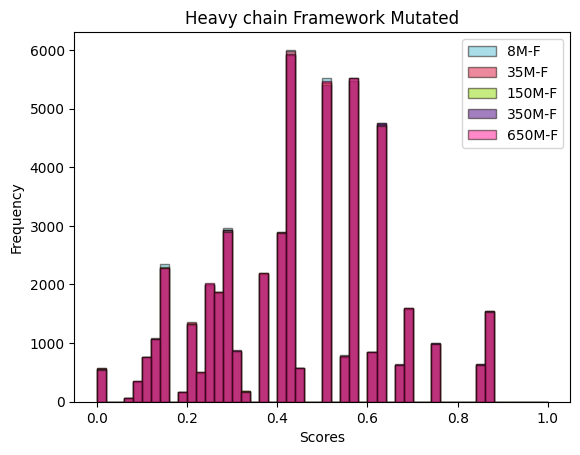

In [7]:
hist_1 = plt.hist(scores_df[(scores_df["Data Type"] == data_type) & (scores_df["Model"]== Mods.get("mod1")) & (scores_df["Study"]== study) & (scores_df["Region"]== reg)][calculation_type], 
        label = Mods.get("mod1"), range = [0,1], bins=50, 
        color = Colors.get("col1"), alpha = 0.5, edgecolor = "#140700")
hist_2 = plt.hist(scores_df[(scores_df["Data Type"] == data_type) & (scores_df["Model"]== Mods.get("mod2")) & (scores_df["Study"]== study) & (scores_df["Region"]== reg)][calculation_type], 
        label = Mods.get("mod2"), alpha = 0.5, range = [0,1], bins=50, 
        color = Colors.get("col2"), edgecolor = "#140700")
hist_3 = plt.hist(scores_df[(scores_df["Data Type"] == data_type) & (scores_df["Model"]== Mods.get("mod3")) & (scores_df["Study"]== study) & (scores_df["Region"]== reg)][calculation_type], 
        label = Mods.get("mod3"), alpha = 0.5, range = [0,1], bins=50, 
        color = Colors.get("col3"), edgecolor = "#140700")
hist_4 = plt.hist(scores_df[(scores_df["Data Type"] == data_type) & (scores_df["Model"]== Mods.get("mod4")) & (scores_df["Study"]== study) & (scores_df["Region"]== reg)][calculation_type], 
        label = Mods.get("mod4"), alpha = 0.5, range = [0,1], bins=50, 
        color = Colors.get("col4"), edgecolor = "#140700")
hist_5 = plt.hist(scores_df[(scores_df["Data Type"] == data_type) & (scores_df["Model"]== Mods.get("mod5")) & (scores_df["Study"]== study) & (scores_df["Region"]== reg)][calculation_type], 
        label = Mods.get("mod5"), alpha = 0.5, range = [0,1], bins=50, 
        color = Colors.get("col5"), edgecolor = "#140700")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, title='Model')
plt.title(title)
plt.ylabel("Frequency")
plt.xlabel("Scores")
plt.legend()
plt.savefig(f"./results/hist-{saved_png}.png", bbox_inches='tight')

## Boxplots

/tmp/ipykernel_41719/3518656486.py:5: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  plot = sns.boxplot(x = "Region", y = calculation_type, data = scores_df[(scores_df["Data Type"] == data_type) & (scores_df["Study"] == study)], hue="Model",
/opt/conda/lib/python3.12/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/opt/conda/lib/python3.12/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/opt/conda/lib/python3.12/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/opt/conda

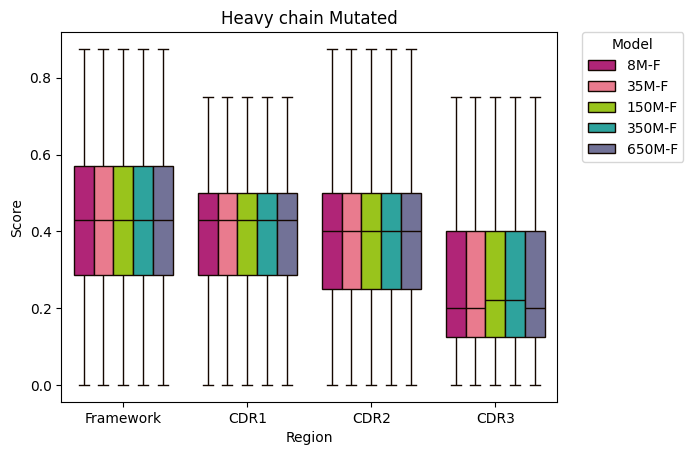

<Figure size 640x480 with 0 Axes>

In [8]:
from pypalettes import load_palette
#Klein and PassionFruit are nice color palettes 


plot = sns.boxplot(x = "Region", y = calculation_type, data = scores_df[(scores_df["Data Type"] == data_type) & (scores_df["Study"] == study)], hue="Model", 
        order = ["Framework", "CDR1", "CDR2", "CDR3"], showfliers = False, palette=load_palette("PassionFruit"), linecolor = "#140700").set(title = f"{chain_type} chain {data_type}")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, title='Model')
plt.ylabel(calculation_type)
plt.show()
plt.savefig(f"./results/box-{study} {chain_type} Chain {data_type}.png", format = "png")

## Heatmap

### regional

In [9]:
'''Initializing a new data frame of the frequency of specific amino acid inferences per true amino acid, exclusive of exact matches.
Ex: A --> R is in letter_scores_df x times, which is recorded in the heat_freqs df. A --> A is not in the dataframe because this represents an exact match.
'''

heat_freqs = letter_scores_df[(letter_scores_df["Data Type"] == data_type) & (letter_scores_df["Study"] == study) & (letter_scores_df["Region"] == reg)].value_counts(['Acc letter', 'Inf letter']).reset_index()
heat_freqs["count"] = heat_freqs["count"].astype(float)

In [10]:
'''Scaling the frquencies of amino acid inferences to be relative to the true amino acid.'''

aa_list = ["A", "R", "N", "D", "C", "E", "Q", "G", "H", "I", "L", "K", "M", "F", "P", "S", "T", "W", "Y", "V"]

for i in aa_list:
    sum = 0
    indx = []
    for j in range(len(heat_freqs)):
        if i == heat_freqs["Acc letter"][j]:
            sum += float(heat_freqs["count"][j])
            indx.append(j)    
        else: pass

    for pos in indx:
        pre_scale_val = float(heat_freqs["count"][pos])        
        heat_freqs.loc[pos, "count"] = round(pre_scale_val/sum, 3)

In [11]:
'''Makes the heat_freqs dataframe have a total of 400 rows by giving all true/inferred amino acid pairs a score of 0 if it is not already in the dataframe.'''

for i in aa_list:
    for j in aa_list:
        if len(heat_freqs[(heat_freqs["Acc letter"] == i) & (heat_freqs["Inf letter"] == j)]) == 0:
           heat_freqs.loc[len(heat_freqs)+1]=[i, j, 0.0000]
        else: pass

# len(heat_freqs)

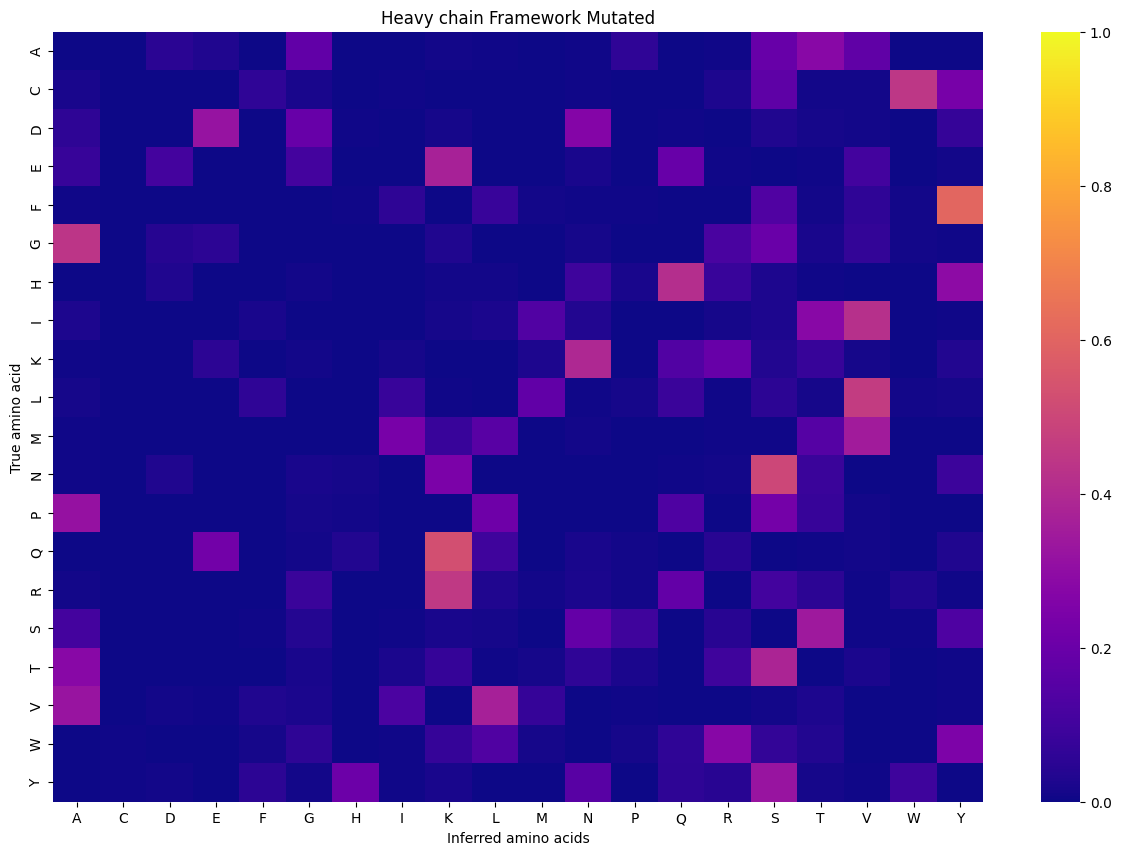

<Figure size 640x480 with 0 Axes>

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import colormaps
'''Nice colors for the heatmap are magma, inferno, RdPu, and plasma.'''

df = sns.load_dataset("tips")
heatmap_data = heat_freqs.pivot_table(index="Acc letter", columns="Inf letter", values="count")
fig, ax = plt.subplots(figsize=(15, 10))
sns.heatmap(heatmap_data, annot=False, vmin = 0, vmax= 1, fmt = ".3f", ax = ax, 
            cmap="plasma").set(xlabel = "Inferred amino acids", ylabel = "True amino acid")
plt.title(title)
plt.show() 
plt.savefig(f"./results/heat-{saved_png}.png", bbox_inches='tight')

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Define the model
model = ols('Metric ~ C(Model)', data=scores_df[(scores_df["Data Type"] == data_type) & (scores_df["Study"]== study) & (scores_df["Region"]=="Framework")]).fit()

# Perform ANOVA
anova_table = sm.stats.anova_lm(model, typ=1)
print(anova_table)